In [ ]:
import uqct 

import torch
import matplotlib.pyplot as plt
from uqct.ct import circular_mask
from uqct.eval.run import setup_experiment
from uqct.metrics import get_metrics

from torch.nn.functional import interpolate

import numpy as np
import h5py
import pandas as pd

%matplotlib inline

In [52]:
dataset = 'lung'
n_angles = 200
max_angle = 180
schedule_length = 32
schedule_start = 10
total_intensity = 1e9
seed = 0

# Setup Experiment
image_range = (0, 1)
sparse = True

gt, experiment, schedule = setup_experiment(
    dataset,
    image_range,
    total_intensity,
    sparse,
    seed,
    schedule_length,
    schedule_start,
    'exp',
    n_angles,
    max_angle
)

print(f"Schedule: {schedule.tolist()}")

Experiment: Experiment(sparse=True, intensities=tensor[1, 200, 1] x∈[3.906e+04, 3.906e+04] μ=3.906e+04 σ=0. cuda:0, counts=tensor[1, 200, 128] n=25600 (100Kb) x∈[1.231e+04, 3.945e+04] μ=2.237e+04 σ=5.586e+03 cuda:0, angles=tensor[200] f64 1.6Kb x∈[0., 179.100] μ=89.550 σ=52.091 cuda:0)
Schedule: [10, 11, 12, 13, 15, 16, 18, 20, 22, 24, 26, 29, 32, 35, 39, 43, 47, 52, 57, 63, 69, 76, 84, 92, 101, 112, 123, 135, 149, 164, 181, 199]


In [53]:
dataset = 'lung'
n_angles = 200
max_angle = 180
schedule_length = 200
schedule_start = 1
total_intensity = 1e9
seed = 0

# Setup Experiment
image_range = (0, 1)
sparse = True

gt, experiment_full, schedule_full = setup_experiment(
    dataset,
    image_range,
    total_intensity,
    sparse,
    seed,
    schedule_length,
    schedule_start,
    'all',
    n_angles,
    max_angle
)

print(f"Schedule: {schedule_full.tolist()}")

Experiment: Experiment(sparse=True, intensities=tensor[1, 200, 1] x∈[3.906e+04, 3.906e+04] μ=3.906e+04 σ=0. cuda:0, counts=tensor[1, 200, 128] n=25600 (100Kb) x∈[1.231e+04, 3.945e+04] μ=2.237e+04 σ=5.586e+03 cuda:0, angles=tensor[200] f64 1.6Kb x∈[0., 179.100] μ=89.550 σ=52.091 cuda:0)
Schedule: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 

In [54]:
base_path = "/home/mgaetzner/Dropbox/eth/uq-xray-ct/results/runs/fbp:lung:1000000000.0:True:0-1:0:2026-01-19 14:55:18.654474"
with h5py.File(f"{base_path}.h5", "r") as f:
    preds = f["preds"][:]
    print(preds.shape)
df = pd.read_parquet(f"{base_path}.parquet")
col_str = "\n".join(map(lambda x: "  - " + str(x), df.columns))
print(f"Columns: \n{col_str}")

print(df)

base_path_full = "/home/mgaetzner/Dropbox/eth/uq-xray-ct/results/runs/fbp:lung:1000000000.0:True:0-1:0:2026-01-19 15:04:50.085724"
with h5py.File(f"{base_path_full}.h5", "r") as f:
    preds_full = f["preds"][:]
    print(preds_full.shape)
df_full = pd.read_parquet(f"{base_path_full}.parquet")
col_str_full = "\n".join(map(lambda x: "  - " + str(x), df_full.columns))
print(f"Columns: \n{col_str_full}")
print(df_full)

(1, 32, 128, 128)
Columns: 
  - psnr
  - ssim
  - rmse
  - zeroone
  - l1
  - nll_pred
  - nll_gt
  - dataset
  - total_intensity
  - sparse
  - image_start_index
  - image_end_index
  - intensity_schedule
  - num_rounds
  - angle_schedule
  - model
  - run_id
  - timestamp
  - slurm_job_id
  - seed
                                                psnr  ... seed
0  [8.284055709838867, 8.474322319030762, 8.65230...  ...    0

[1 rows x 20 columns]
(1, 198, 128, 128)
Columns: 
  - psnr
  - ssim
  - rmse
  - zeroone
  - l1
  - nll_pred
  - nll_gt
  - dataset
  - total_intensity
  - sparse
  - image_start_index
  - image_end_index
  - intensity_schedule
  - num_rounds
  - angle_schedule
  - model
  - run_id
  - timestamp
  - slurm_job_id
  - seed
                                                psnr  ... seed
0  [4.753420829772949, 5.843155860900879, 6.39853...  ...    0

[1 rows x 20 columns]


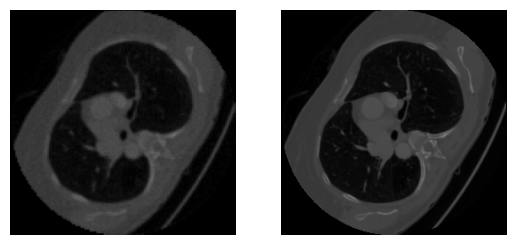

In [62]:
fig, axes = plt.subplots(1, 2)
axes[0].imshow(preds[0, -1], cmap="gray", vmin=0, vmax=1)
axes[1].imshow(gt[0].cpu(), cmap="gray", vmin=0, vmax=1)
for ax in axes:
    ax.set_axis_off()

Text(199, 31.611068725585938, '(199, 31.61)')

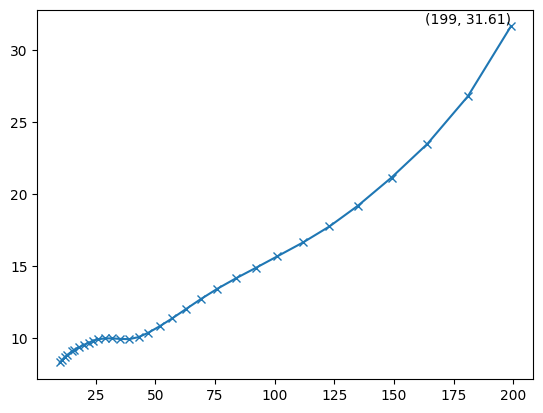

In [64]:
plt.plot(schedule.cpu(), df['psnr'][0], marker='x')
plt.text(schedule.cpu()[-1], df['psnr'][0][-1], f"({round(schedule.cpu()[-1].item(), 2)}, {round(df['psnr'][0][-1], 2)})", va='bottom', ha='right')

In [ ]:
kkkkk